Extended Data Figure 7 — single-modality Root recovery heatmaps


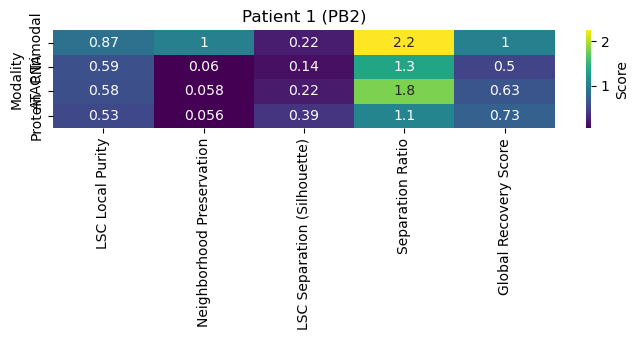

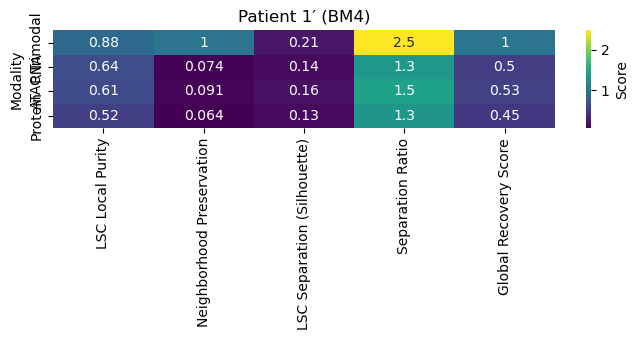

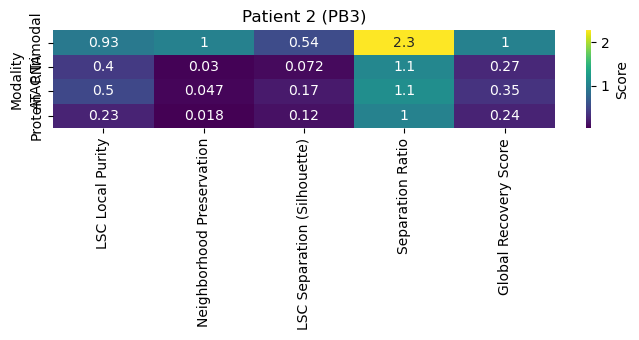

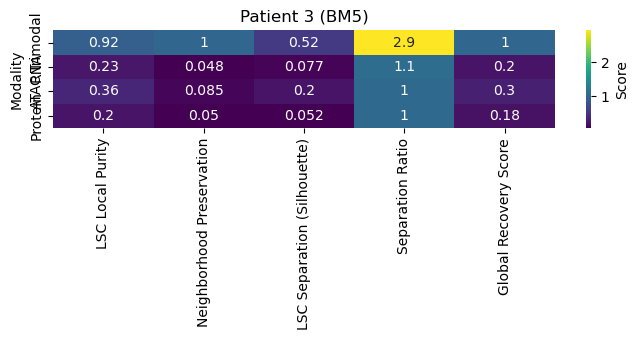

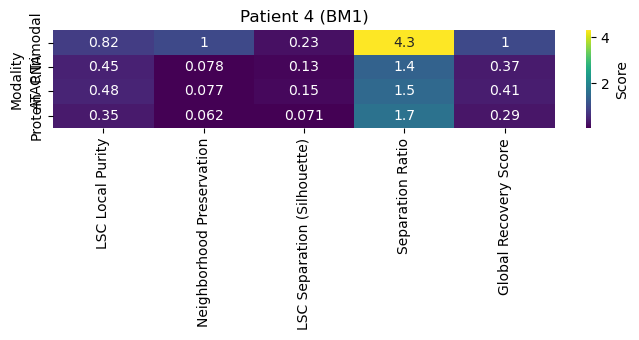

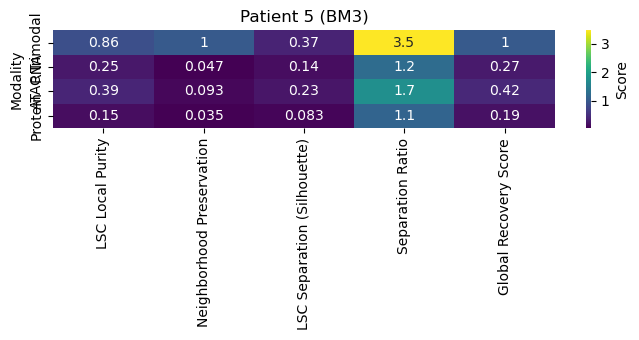

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

DATA = Path("PATH_TO_DATA")
ANALYSIS = DATA / "New_Analysis/Multimodal/Analysis"

METRICS = [
    "LSC Local Purity",
    "Neighborhood Preservation",
    "LSC Separation (Silhouette)",
    "Separation Ratio",
    "Global Recovery Score",
]

SAMPLES = [
    ("Patient 1", "PB2"),
    ("Patient 1\u2032", "BM4"),
    ("Patient 2", "PB3"),
    ("Patient 3", "BM5"),
    ("Patient 4", "BM1"),
    ("Patient 5", "BM3"),
]


def load_heatmap_table(lab):
    folder = ANALYSIS / lab
    plot = folder / "LSC_plot_table.csv"
    summary = folder / "LSC_recovery_summary.csv"
    path = plot if plot.exists() else summary
    df = pd.read_csv(path)
    if "Modality" not in df.columns:
        raise ValueError(f"{path} is not the clean plot table")
    return df.set_index("Modality")[METRICS]


for label, lab in SAMPLES:
    heatmap_df = load_heatmap_table(lab)
    plt.figure(figsize=(7, 3.5))
    sns.heatmap(
        heatmap_df,
        annot=True,
        cmap="viridis",
        cbar_kws={"label": "Score"},
    )
    plt.title(f"{label} ({lab})")
    plt.tight_layout()
    plt.show()
